In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carichiamo le fermate
fermate = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\Tramhaltes_en_metrostations_2025.json")
print(f"Fermate caricate: {len(fermate)}")
print(fermate.columns.tolist())
fermate.head()

Fermate caricate: 236
['Naam', 'Modaliteit', 'Lijn', 'Lijn_select', 'RADIUS', 'Label', 'geometry']


,Naam,Modaliteit,Lijn,Lijn_select,RADIUS,Label,geometry
0,Nieuwezijds Kolk,Tram,2 | 12 | 17,02|12|17,5,2 | 12 | 17 - Nieuwezijds Kolk,POINT (4.89334 52.37607)
1,Surinameplein / Curaçaostraat,Tram,1 | 17 | 27,01|17|27,5,1 | 17 | 27 - Surinameplein / Curaçaostraat,POINT (4.85312 52.35838)
2,Johan Huizingalaan,Tram,1 | 17 | 27,01|17|27,5,1 | 17 | 27 - Johan Huizingalaan,POINT (4.82732 52.35782)
3,Prinsengracht,Tram,2 | 12 | 17,02|12|17,5,2 | 12 | 17 - Prinsengracht,POINT (4.88447 52.36502)
4,Keizergracht,Tram,2 | 12 | 17,02|12|17,5,2 | 12 | 17 - Keizergracht,POINT (4.88645 52.36596)


In [2]:
print("Modalità di trasporto:")
print(fermate['Modaliteit'].value_counts())

# Carichiamo anche le linee
linee = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\Tram-en_metrolijnen_2025_lnglat.json")
print(f"\nLinee caricate: {len(linee)}")
print(linee.columns.tolist())
print(linee['Modaliteit'].value_counts() if 'Modaliteit' in linee.columns else linee.head())

Modalità di trasporto:
Modaliteit
Tram     197
Metro     39
Name: count, dtype: int64

Linee caricate: 193
['Modaliteit', 'Lijn', 'Lijn_select', 'geometry']
Modaliteit
Tram     182
Metro     11
Name: count, dtype: int64


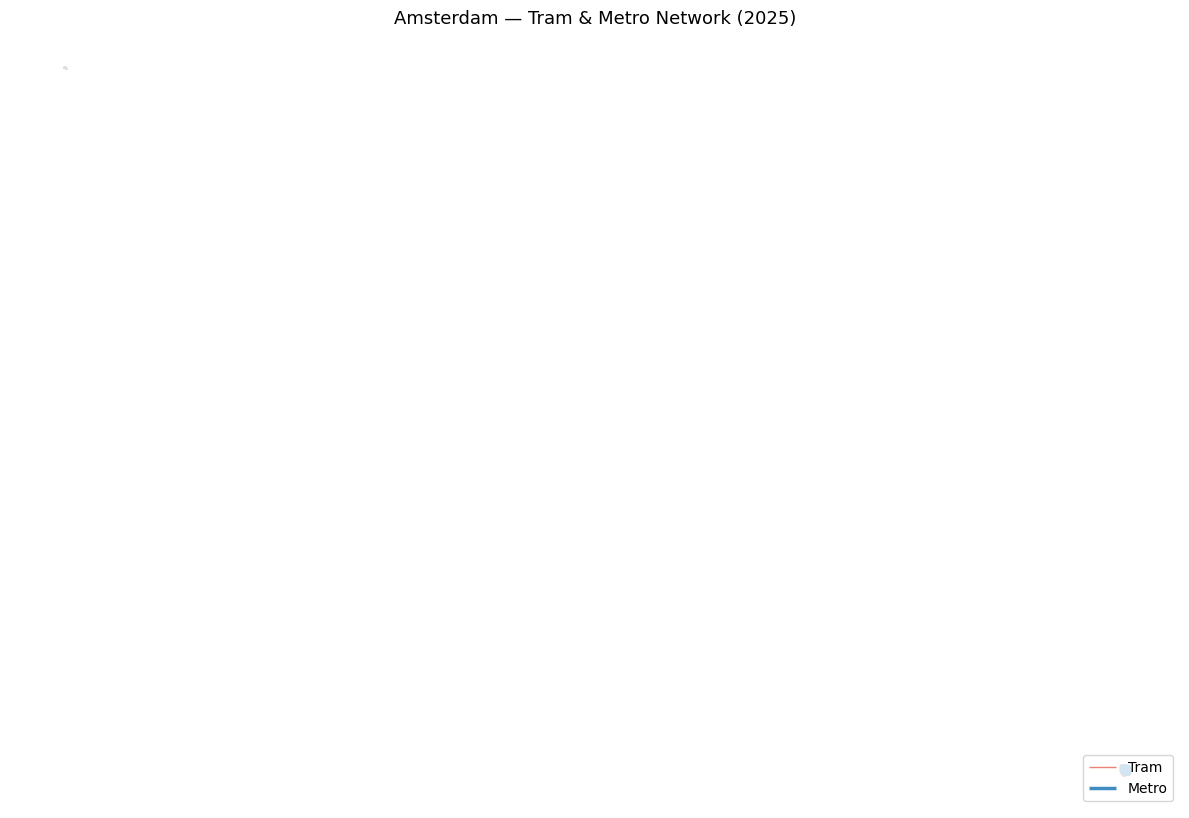

In [3]:
from shapely.ops import transform

# Correggiamo le coordinate delle fermate
fermate['geometry'] = fermate['geometry'].apply(
    lambda geom: transform(lambda x, y: (y, x), geom)
)
fermate = fermate.set_crs("EPSG:4326").to_crs("EPSG:28992")

# Correggiamo le coordinate delle linee
linee['geometry'] = linee['geometry'].apply(
    lambda geom: transform(lambda x, y: (y, x), geom)
)
linee = linee.set_crs("EPSG:4326").to_crs("EPSG:28992")

# Carichiamo i quartieri come sfondo
buurten = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten_proj = buurten.to_crs("EPSG:28992")

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Sfondo
buurten_proj.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Linee tram (rosse) e metro (blu)
linee[linee['Modaliteit'] == 'Tram'].plot(ax=ax, color='#e74c3c', linewidth=1, alpha=0.7, label='Tram')
linee[linee['Modaliteit'] == 'Metro'].plot(ax=ax, color='#2980b9', linewidth=2.5, alpha=0.9, label='Metro')

# Fermate tram (rosse) e metro (blu)
fermate[fermate['Modaliteit'] == 'Tram'].plot(ax=ax, color='#e74c3c', markersize=15, zorder=5)
fermate[fermate['Modaliteit'] == 'Metro'].plot(ax=ax, color='#2980b9', markersize=25, zorder=5, marker='s')

ax.legend(fontsize=10, loc='lower right')
ax.set_title('Amsterdam — Tram & Metro Network (2025)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_transport_network.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
print(f"Bounds fermate: {fermate.total_bounds}")
print(f"Bounds linee: {linee.total_bounds}")
print(f"Bounds buurten: {buurten_proj.total_bounds}")

Bounds fermate: [ 6393661.52266851 -3691818.75894152  6416502.74745123 -3659403.7921613 ]
Bounds linee: [ 6393661.52266851 -3691933.9021407   6416643.82553968 -3659270.0420287 ]
Bounds buurten: [110188.97695395 476708.7081128  135933.02464056 493893.87221555]


In [5]:
# Ricarichiamo SENZA swap
fermate = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\Tramhaltes_en_metrostations_2025.json")
fermate = fermate.set_crs("EPSG:4326").to_crs("EPSG:28992")

linee = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\Tram-en_metrolijnen_2025_lnglat.json")
linee = linee.set_crs("EPSG:4326").to_crs("EPSG:28992")

print(f"Bounds fermate: {fermate.total_bounds}")
print(f"Bounds linee: {linee.total_bounds}")

Bounds fermate: [113275.86703043 472047.85191016 128911.44686669 490546.24537021]
Bounds linee: [113193.03728794 472048.05882616 128965.17005848 491007.860516  ]


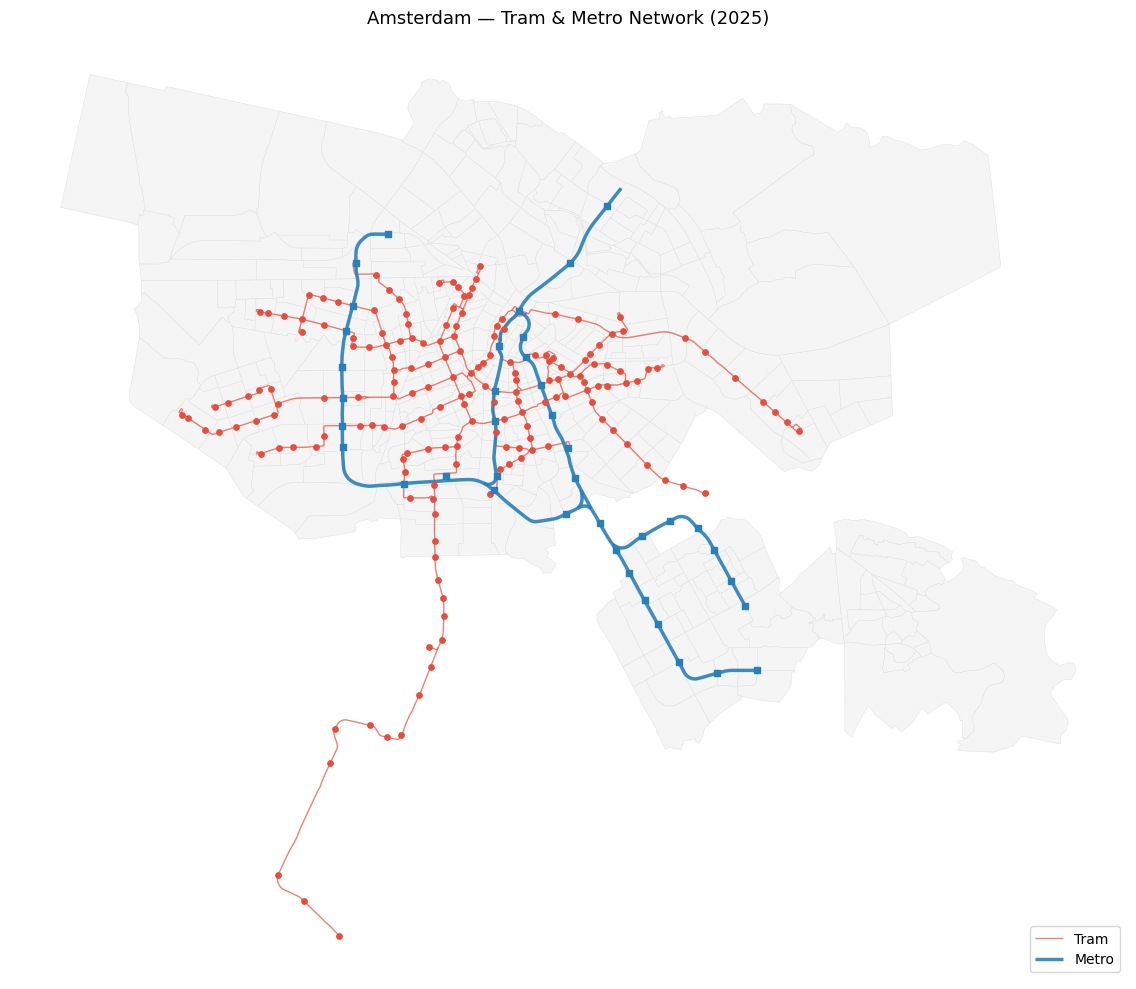

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Sfondo
buurten_proj.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Linee tram (rosse) e metro (blu)
linee[linee['Modaliteit'] == 'Tram'].plot(ax=ax, color='#e74c3c', linewidth=1, alpha=0.7, label='Tram')
linee[linee['Modaliteit'] == 'Metro'].plot(ax=ax, color='#2980b9', linewidth=2.5, alpha=0.9, label='Metro')

# Fermate tram (rosse) e metro (blu)
fermate[fermate['Modaliteit'] == 'Tram'].plot(ax=ax, color='#e74c3c', markersize=15, zorder=5)
fermate[fermate['Modaliteit'] == 'Metro'].plot(ax=ax, color='#2980b9', markersize=25, zorder=5, marker='s')

ax.legend(fontsize=10, loc='lower right')
ax.set_title('Amsterdam — Tram & Metro Network (2025)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_transport_network.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
import pandas as pd

# Ricarichiamo la popolazione CBS
obs = pd.read_csv(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\Observations.csv", sep=';')
codes = pd.read_csv(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\WijkenEnBuurtenCodes.csv", sep=';')

obs.columns = [c.replace('ï»¿', '') for c in obs.columns]
amsterdam_buurten = codes[codes['Identifier'].str.startswith('BU0363', na=False)]

pop_data = obs[
    (obs['WijkenEnBuurten'].isin(amsterdam_buurten['Identifier'])) &
    (obs['Measure'] == 'T001036') &
    (obs['Value'].notna())
].copy()

pop_named = pop_data.merge(
    amsterdam_buurten[['Identifier', 'Title']],
    left_on='WijkenEnBuurten', right_on='Identifier', how='left'
)
pop_named['Value'] = pd.to_numeric(pop_named['Value'], errors='coerce')

# Uniamo con i buurten
buurten_pop = buurten_proj.merge(
    pop_named[['Identifier', 'Value']],
    left_on='CBS_Buurtcode', right_on='Identifier', how='left'
)
buurten_pop = buurten_pop.rename(columns={'Value': 'Popolazione'})

print(f"Buurt con popolazione: {buurten_pop['Popolazione'].notna().sum()}")
print(f"Popolazione totale: {buurten_pop['Popolazione'].sum():,.0f}")

Buurt con popolazione: 517
Popolazione totale: 917,890


In [8]:
# Buffer 500m attorno a tutte le fermate
buffer_union = fermate.geometry.buffer(500).union_all()

# Per ogni buurt calcoliamo la percentuale di area coperta dal buffer
buurten_pop['area_totale'] = buurten_pop.geometry.area
buurten_pop['area_coperta'] = buurten_pop.geometry.intersection(buffer_union).area
buurten_pop['perc_area'] = (buurten_pop['area_coperta'] / buurten_pop['area_totale']).clip(0, 1)

# Popolazione accessibile
buurten_pop['pop_accessibile'] = buurten_pop['Popolazione'] * buurten_pop['perc_area']

# Risultato globale
pop_totale = buurten_pop['Popolazione'].sum()
pop_accessibile = buurten_pop['pop_accessibile'].sum()
perc_pop = pop_accessibile / pop_totale * 100

print(f"Popolazione totale: {pop_totale:,.0f}")
print(f"Popolazione entro 500m da tram/metro: {pop_accessibile:,.0f}")
print(f"Percentuale: {perc_pop:.1f}%")

Popolazione totale: 917,890
Popolazione entro 500m da tram/metro: 665,754
Percentuale: 72.5%


In [9]:
access_stadsdeel = buurten_pop.groupby('Stadsdeel').agg(
    Pop_totale=('Popolazione', 'sum'),
    Pop_accessibile=('pop_accessibile', 'sum')
).reset_index()

access_stadsdeel['Perc_accessibile'] = (
    access_stadsdeel['Pop_accessibile'] / access_stadsdeel['Pop_totale'] * 100
).round(1)

print(access_stadsdeel[['Stadsdeel', 'Pop_totale', 'Perc_accessibile']]
      .sort_values('Perc_accessibile', ascending=False))

    Stadsdeel  Pop_totale  Perc_accessibile
0     Centrum     89980.0              95.8
5        West    148555.0              93.8
7        Zuid    148035.0              87.3
1  Nieuw-West    163425.0              82.8
3        Oost    145835.0              78.6
8    Zuidoost     90385.0              54.0
2       Noord    106885.0              11.5
4       Weesp     23770.0               0.0
6   Westpoort      1020.0               0.0


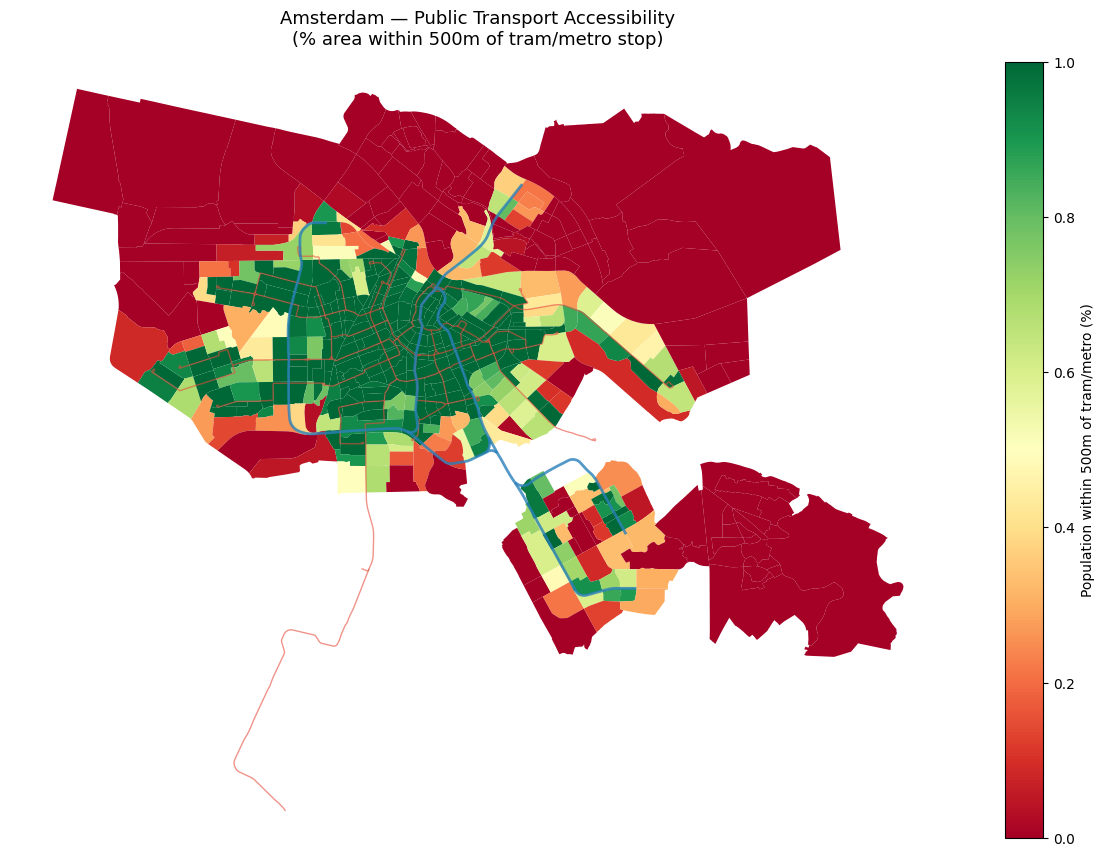

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

buurten_pop.plot(
    column='perc_area',
    cmap='RdYlGn',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Population within 500m of tram/metro (%)', 'shrink': 0.8},
    missing_kwds={'color': 'lightgrey'}
)

# Sovrapponiamo le linee
linee[linee['Modaliteit'] == 'Tram'].plot(ax=ax, color='#e74c3c', linewidth=1, alpha=0.6)
linee[linee['Modaliteit'] == 'Metro'].plot(ax=ax, color='#2980b9', linewidth=2, alpha=0.8)

ax.set_title('Amsterdam — Public Transport Accessibility\n(% area within 500m of tram/metro stop)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_transport_accessibility.png', dpi=150, bbox_inches='tight')
plt.show()